# 01. EDA и первичная подготовка данных

В этом ноутбуке проводится первичный анализ датасета Food.com Recipes and Interactions: загрузка данных, проверка структуры таблиц, анализ пропусков, дубликатов и распределений, а также подготовка целевой переменной качества рецепта.

## Импорт библиотек и функций предобработки

Подключаем базовые библиотеки для анализа данных и визуализации.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import (
    load_raw_data,
    print_initial_overview,
    clean_recipes,
    clean_interactions,
    missing_report,
    build_recipe_target,
    engineer_features,
    make_outlier_report,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Загрузка исходных данных

In [2]:
recipes, interactions = load_raw_data("../data/raw")

## Первичный обзор датасета

In [3]:
print_initial_overview(recipes, interactions)

recipes shape: (231637, 12)
interactions shape: (1132367, 5)

Первые 3 строки recipes:
                                         name      id  minutes  contributor_id   submitted                                                                                                                                                                                                                                                                              tags                                   nutrition  n_steps                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

## Очистка данных

Удаляем дубликаты, приводим типы, фильтруем некорректные значения и анализируем пропуски.

In [4]:
recipes = clean_recipes(recipes)
interactions = clean_interactions(interactions)

print("recipes shape after cleaning:", recipes.shape)
print("interactions shape after cleaning:", interactions.shape)

missing_report(recipes, "recipes")
missing_report(interactions, "interactions")

recipes duplicates by full row: 0
recipes duplicates by recipe_id: 0
interactions duplicates by full row: 0
recipes shape after cleaning: (230542, 12)
interactions shape after cleaning: (1071520, 5)

=== Missing report: recipes ===
             missing_cnt  missing_pct dtype
description         4314         1.87   str
name                   1         0.00   str

=== Missing report: interactions ===
        missing_cnt  missing_pct dtype
review          169         0.02   str


,missing_cnt,missing_pct,dtype
review,169,0.02,str
user_id,0,0.00,int64
recipe_id,0,0.00,int64
date,0,0.00,datetime64[us]
rating,0,0.00,int64


## Формирование целевой переменной

Разбиваем рецепты на три класса качества:
- bad
- normal
- good

Классы строятся по квантильным границам среднего рейтинга.

In [5]:
data = build_recipe_target(recipes, interactions, min_rating_count=10)

raw thresholds: 4.625 4.857142857142857
rounded for report: 4.6 4.9
final recipe-level dataset shape: (19965, 17)

Распределение классов:
recipe_quality_name
normal    7917
bad       6044
good      6004

Доли классов:
recipe_quality_name
normal    0.3965
bad       0.3027
good      0.3007

Проверка диапазонов mean_rating по классам:
                     count     min     max    mean
recipe_quality_name                               
bad                   6044  2.1333  4.6250  4.4028
good                  6004  4.8571  5.0000  4.9348
normal                7917  4.6259  4.8559  4.7505


## Feature engineering

Создаём дополнительные признаки на основе:
- длины списков;
- длины текстов;
- пищевой ценности;
- производных отношений;
- бинарных флагов.

In [6]:
data = engineer_features(data)

Количество столбцов после feature engineering: 52
                                name  recipe_id  minutes  contributor_id  submitted                                                                                                                                                                                                                                                                                                                                                tags                                     nutrition  n_steps                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

## Анализ выбросов

In [7]:
outliers_df = make_outlier_report(data)
outliers_df.head(20)

                feature     n  outliers_cnt  outliers_pct         low       high
                minutes 19965          2213         11.08  -47.500000 132.500000
       minutes_per_step 19965          2187         10.95   -5.000000  15.000000
              sugar_pdv 19965          2094         10.49  -74.500000 145.500000
calories_per_ingredient 19965          1668          8.35  -39.541667 121.591667
             sodium_pdv 19965          1426          7.14  -37.500000  78.500000
               calories 19965          1383          6.93 -319.550000 991.250000
          total_fat_pdv 19965          1361          6.82  -38.500000  85.500000
      saturated_fat_pdv 19965          1356          6.79  -57.500000 114.500000
              carbs_pdv 19965          1291          6.47  -14.000000  34.000000
   ingredients_per_step 19965          1162          5.82   -0.357143   2.500000
        description_len 19965          1094          5.48 -186.500000 569.500000
            protein_pdv 1996

,feature,n,outliers_cnt,outliers_pct,low,high
0,minutes,19965,2213,11.08,-47.500000,132.500000
13,minutes_per_step,19965,2187,10.95,-5.000000,15.000000
5,sugar_pdv,19965,2094,10.49,-74.500000,145.500000
15,calories_per_ingredient,19965,1668,8.35,-39.541667,121.591667
6,sodium_pdv,19965,1426,7.14,-37.500000,78.500000
3,calories,19965,1383,6.93,-319.550000,991.250000
4,total_fat_pdv,19965,1361,6.82,-38.500000,85.500000
8,saturated_fat_pdv,19965,1356,6.79,-57.500000,114.500000
9,carbs_pdv,19965,1291,6.47,-14.000000,34.000000
14,ingredients_per_step,19965,1162,5.82,-0.357143,2.500000


## Визуализация

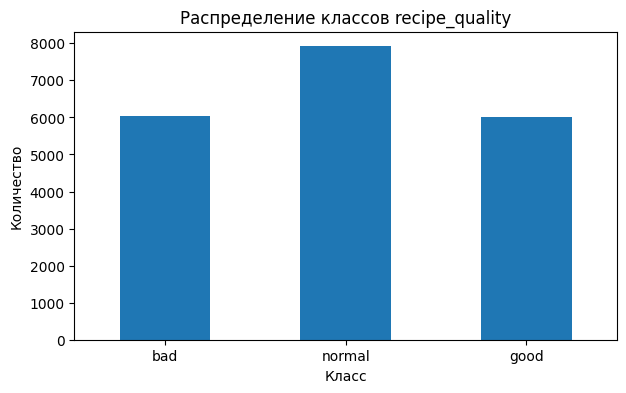

In [8]:
class_order = ["bad", "normal", "good"]

plt.figure(figsize=(7, 4))
data["recipe_quality_name"].value_counts().reindex(class_order).plot(kind="bar")
plt.title("Распределение классов recipe_quality")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

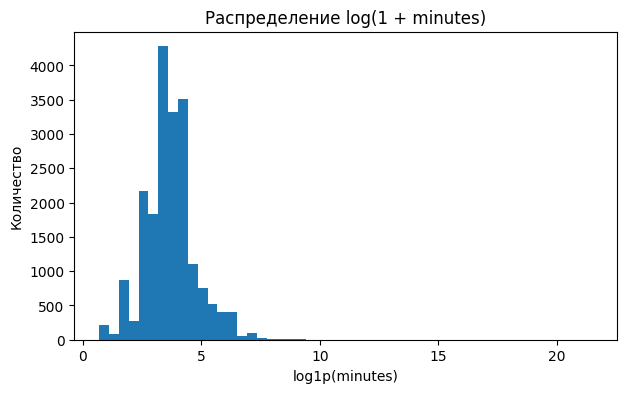

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(np.log1p(data["minutes"]), bins=50)
plt.title("Распределение log(1 + minutes)")
plt.xlabel("log1p(minutes)")
plt.ylabel("Количество")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_43188\94932139.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(minutes_groups, labels=class_order, showfliers=False)


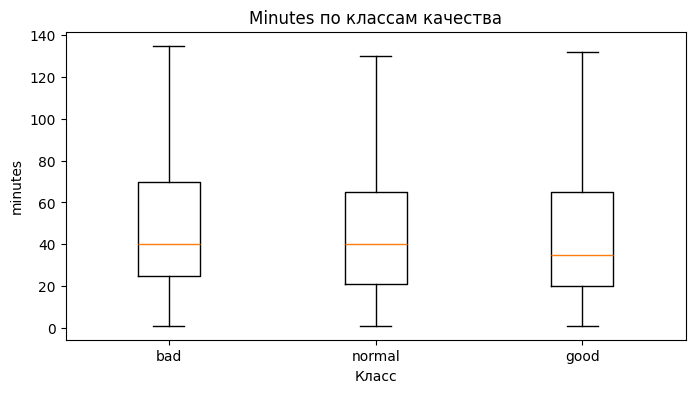

In [10]:
plt.figure(figsize=(8, 4))
minutes_groups = [
    data.loc[data["recipe_quality_name"] == cls, "minutes"].dropna()
    for cls in class_order
]
plt.boxplot(minutes_groups, labels=class_order, showfliers=False)
plt.title("Minutes по классам качества")
plt.xlabel("Класс")
plt.ylabel("minutes")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_43188\2980101959.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ingredients_groups, labels=class_order, showfliers=False)


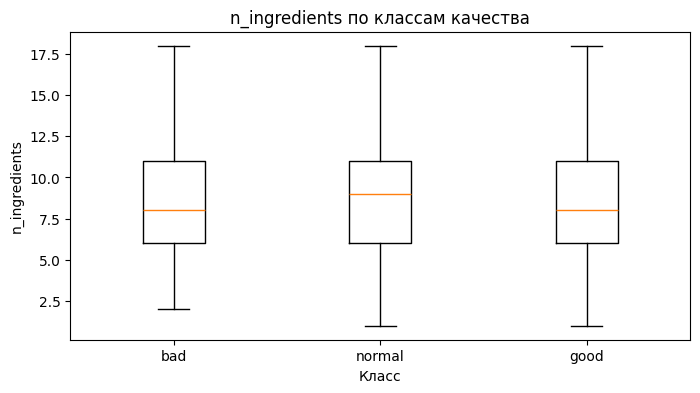

In [11]:
plt.figure(figsize=(8, 4))
ingredients_groups = [
    data.loc[data["recipe_quality_name"] == cls, "n_ingredients"].dropna()
    for cls in class_order
]
plt.boxplot(ingredients_groups, labels=class_order, showfliers=False)
plt.title("n_ingredients по классам качества")
plt.xlabel("Класс")
plt.ylabel("n_ingredients")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_43188\1746240477.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(steps_groups, labels=class_order, showfliers=False)


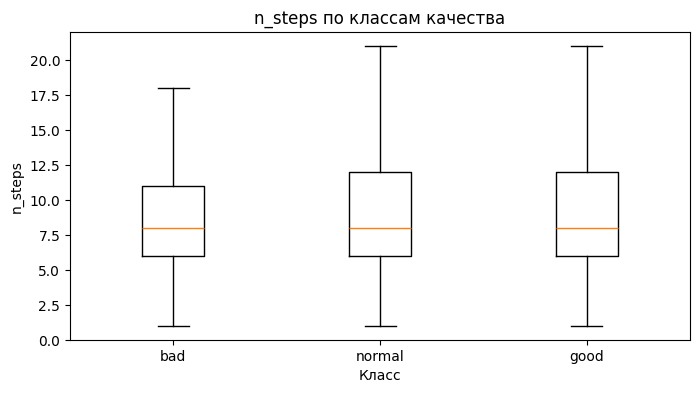

In [12]:
plt.figure(figsize=(8, 4))
steps_groups = [
    data.loc[data["recipe_quality_name"] == cls, "n_steps"].dropna()
    for cls in class_order
]
plt.boxplot(steps_groups, labels=class_order, showfliers=False)
plt.title("n_steps по классам качества")
plt.xlabel("Класс")
plt.ylabel("n_steps")
plt.show()

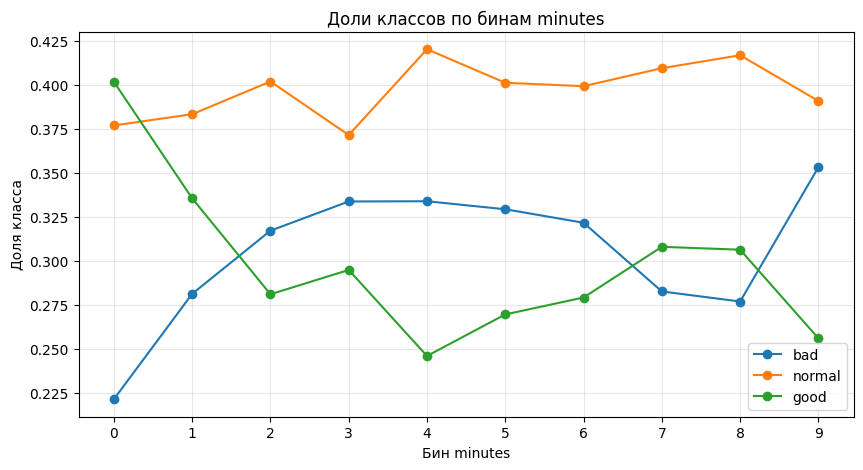

In [13]:
tmp = data[["minutes", "recipe_quality_name"]].dropna().copy()
tmp["minutes_bin"] = pd.qcut(tmp["minutes"], q=10, duplicates="drop")

share_table = (
    pd.crosstab(tmp["minutes_bin"], tmp["recipe_quality_name"], normalize="index")
    .reindex(columns=class_order)
)

plt.figure(figsize=(10, 5))
for cls in class_order:
    plt.plot(range(len(share_table)), share_table[cls].values, marker="o", label=cls)

plt.title("Доли классов по бинам minutes")
plt.xlabel("Бин minutes")
plt.ylabel("Доля класса")
plt.xticks(range(len(share_table)), [str(i) for i in range(len(share_table))])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

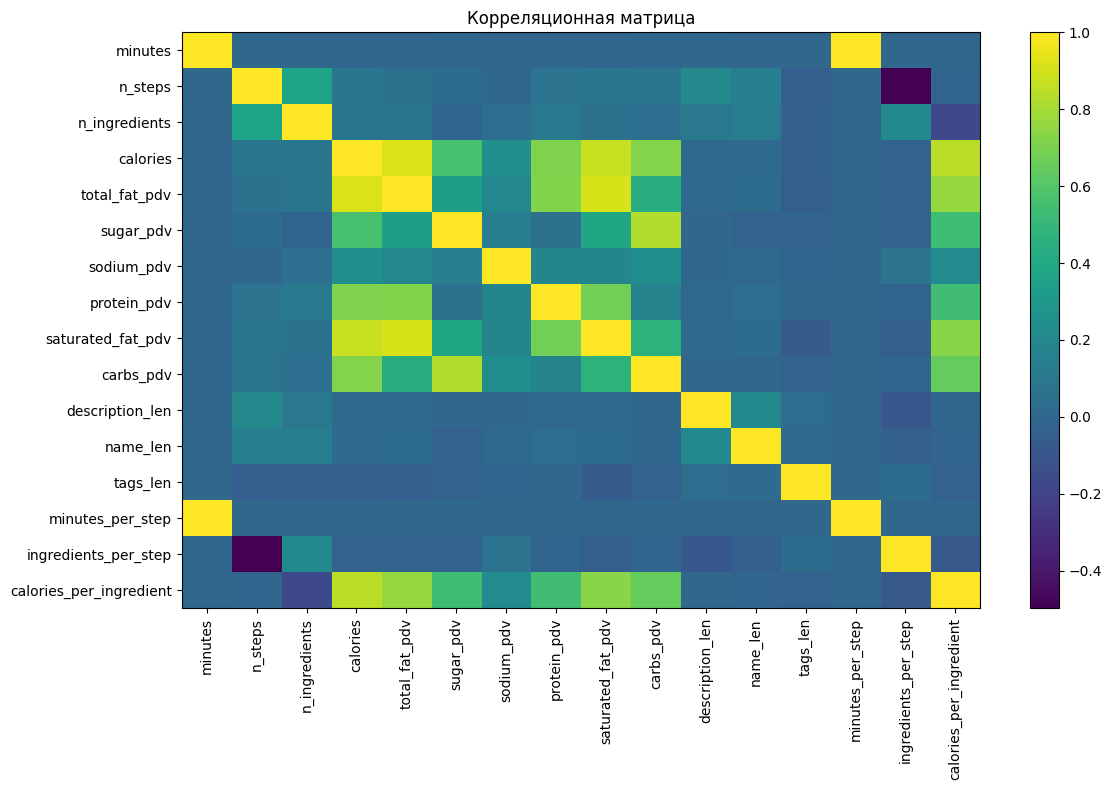

In [14]:
corr_cols = [
    "minutes", "n_steps", "n_ingredients",
    "calories", "total_fat_pdv", "sugar_pdv", "sodium_pdv",
    "protein_pdv", "saturated_fat_pdv", "carbs_pdv",
    "description_len", "name_len", "tags_len",
    "minutes_per_step", "ingredients_per_step", "calories_per_ingredient"
]
corr_cols = [c for c in corr_cols if c in data.columns]

corr = data[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()